<a href="https://colab.research.google.com/github/FahimAlaviRidoy/MLDLassisment3/blob/main/Assisment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install captum grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 120.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 44.4 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=6ef5971bb5844b60b6156a910472b462d06283f9fb83d054fb2feb935945d821
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [5]:
import zipfile
import os

# Define the path to your zip file and the extraction directory
zip_path = '/archive.zip'  # Change this if your file has a different name
extract_path = './brain_tumor_dataset'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

# The standard Kaggle dataset usually extracts into 'Training' and 'Testing' folders.
train_dir = os.path.join(extract_path, 'Training')
test_dir = os.path.join(extract_path, 'Testing')

Dataset extracted successfully.


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# XAI Imports
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Inverse transform for visualizing images later
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print(f"Classes: {class_names}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
def get_model(model_name="efficientnet_b0", num_classes=4):
    if model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_b3":
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        raise ValueError("Model not supported")
    return model

# Initialize model
model_type = "efficientnet_b0" # Change to "resnet50" or "efficientnet_b3" as needed
model = get_model(model_type, num_classes=len(class_names)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s]


In [9]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Acc: {100.*correct/total:.2f}%")

Epoch 1/5 | Loss: 0.2711 | Acc: 90.36%
Epoch 2/5 | Loss: 0.1118 | Acc: 96.20%
Epoch 3/5 | Loss: 0.0802 | Acc: 97.11%
Epoch 4/5 | Loss: 0.0489 | Acc: 98.39%
Epoch 5/5 | Loss: 0.0433 | Acc: 98.62%


Classification Report:

              precision    recall  f1-score   support

      glioma       0.99      0.80      0.89       400
  meningioma       0.90      0.96      0.93       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.96      1.00      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



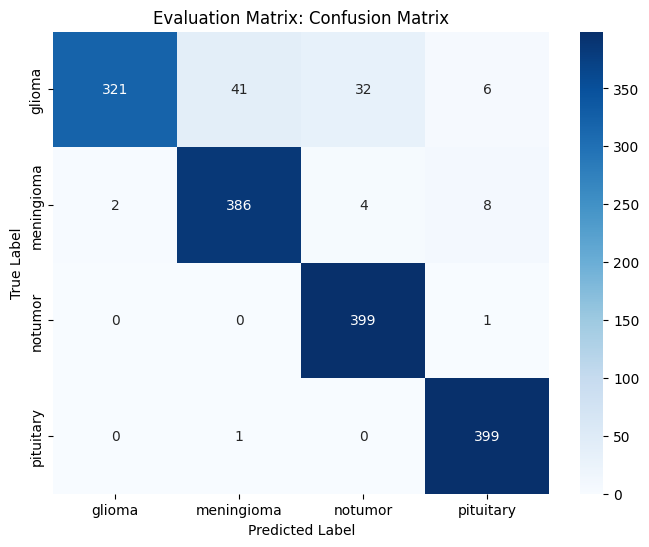

In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Evaluation Matrix: Confusion Matrix')
plt.show()

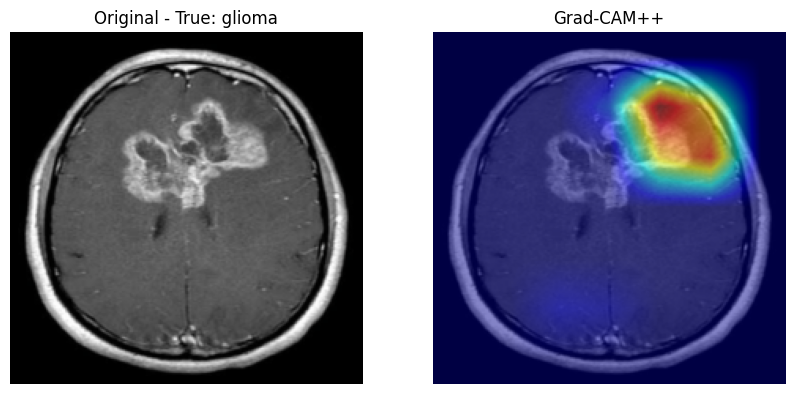

In [11]:
# Helper function to get an image from the test set
def get_sample_image(loader):
    inputs, labels = next(iter(loader))
    return inputs[0].unsqueeze(0), labels[0]

input_tensor, true_label = get_sample_image(test_loader)
input_tensor = input_tensor.to(device)

# Target layer for Grad-CAM
# If using ResNet50, use: target_layers = [model.layer4[-1]]
# If using EfficientNet, use the last block in the features:
target_layers = [model.features[-1]]

cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(true_label.item())]

# Generate CAM
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# Visualize
rgb_img = inv_normalize(input_tensor.squeeze(0).cpu()).permute(1, 2, 0).numpy()
rgb_img = np.clip(rgb_img, 0, 1) # Ensure values are between 0 and 1
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title(f"Original - True: {class_names[true_label.item()]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title("Grad-CAM++")
plt.axis('off')
plt.show()

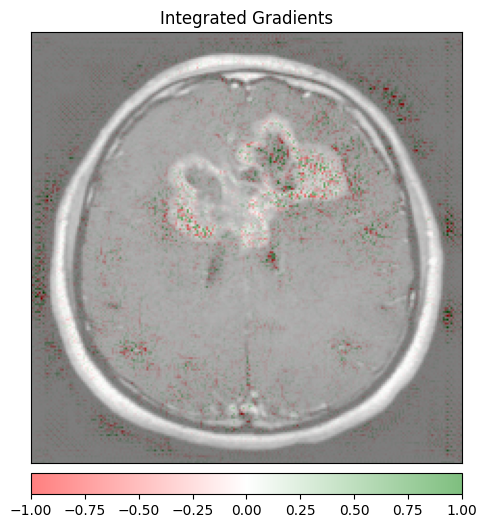

In [12]:
ig = IntegratedGradients(model)

# Compute attributions
attributions, delta = ig.attribute(input_tensor, target=true_label.item(), return_convergence_delta=True)

# Prepare for visualization
attributions = attributions.squeeze(0).cpu().detach().numpy()
attributions = np.transpose(attributions, (1, 2, 0)) # Channel last for Captum viz

# Captum visualization
_ = viz.visualize_image_attr(
    attributions,
    rgb_img,
    method="blended_heat_map",
    sign="all",
    show_colorbar=True,
    title="Integrated Gradients"
)